# 2. Classifying price bands: k-NN and a decision tree

The original project's headline result was a k-nearest-neighbours classifier
that reached "about 72%" accuracy predicting whether an LGA's median house
price was Low, Medium or High from its offence rate and gambling loss per head.

This notebook reproduces that, then asks three questions the original did not:

1. **What does doing nothing score?** No baseline was ever computed.
2. **What happens when the two features are put on the same scale?** They differ
   by a factor of about 20, and k-NN measures Euclidean distance.
3. **What happens when a council cannot appear in both the training and the test
   set?** Notebook 1 showed that 97% of the offence rate's variation is between
   councils, so a row-wise split lets the model recognise councils instead of
   learning the relationship.

Every accuracy below is written to `results/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

from vichouse import config, modelling as M, plotting
from vichouse.build_dataset import FEATURES, TARGET
from vichouse.config import K_RANGE, PRICE_LABELS, RESULTS, SEED

plotting.apply_style()
RESULTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(config.MODELLING_DATASET_CSV)
X = df[FEATURES]
y = df[TARGET]
groups = df["LGA"]

print(f"{len(df)} rows, {groups.nunique()} councils, features: {FEATURES}")

170 rows, 34 councils, features: ['Offence Rate', 'EGM Rate']


## 2.1 Baselines: what does doing nothing score?

This is the number the original project was missing. Without it, "0.66 accuracy"
cannot be interpreted at all.

In [2]:
baselines = M.classification_baselines(X, y)
baseline = baselines["majority class"]
for name, score in baselines.items():
    print(f"{name:20s} {score:.4f}")
print(
    f"\nAlways guessing Medium scores {baseline:.4f}. "
    "That is the bar."
)

majority class       0.4529
stratified random    0.3853
uniform random       0.3638

Always guessing Medium scores 0.4529. That is the bar.


## 2.2 Reproducing the original protocol

The original drew 100 random row-wise splits for each k from 1 to 20 and
averaged the accuracy. It did this without a seed, so the published numbers
cannot be reproduced exactly; the version here is seeded and stratified, which
is why it does not land on precisely the same values.

The report's figures, for comparison: a peak mean of **0.66 at k = 13**, and a
single lucky split at k = 13 that gave **0.7273**, quoted as "about 72%".

In [3]:
rows = []
for k in K_RANGE:
    for scaled in (False, True):
        estimator = M.knn(k, scale=scaled)
        resample = M.resample_scores(estimator, X, y)
        rowwise = M.repeated_stratified_cv(estimator, X, y)
        grouped = M.grouped_cv(estimator, X, y, groups)
        rows.append(
            {
                "k": k,
                "scaled": scaled,
                "resample_mean": resample.mean(),
                "resample_sd": resample.std(ddof=1),
                "rowwise_cv_mean": rowwise.mean(),
                "rowwise_cv_sd": rowwise.std(ddof=1),
                "grouped_cv_mean": grouped.mean(),
                "grouped_cv_sd": grouped.std(ddof=1),
            }
        )

sweep = pd.DataFrame(rows)
sweep.round(4).to_csv(RESULTS / "knn_k_sweep.csv", index=False)

unscaled = sweep[~sweep["scaled"]]
best_k = int(unscaled.loc[unscaled["rowwise_cv_mean"].idxmax(), "k"])
best_rowwise = unscaled["rowwise_cv_mean"].max()
print(f"unscaled, row-wise CV: best k = {best_k}, accuracy {best_rowwise:.4f}")
print(f"report's equivalent:   best k = 13, accuracy 0.66")

unscaled, row-wise CV: best k = 15, accuracy 0.6471
report's equivalent:   best k = 13, accuracy 0.66


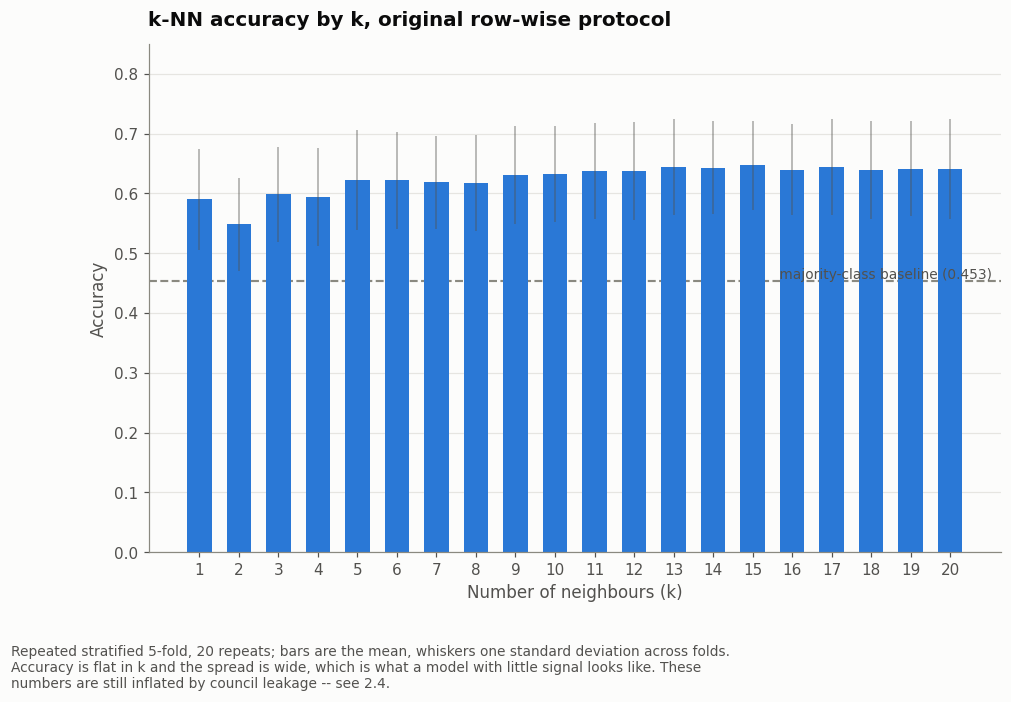

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    unscaled["k"], unscaled["rowwise_cv_mean"],
    color=plotting.BLUE, width=0.62, zorder=2,
)
ax.errorbar(
    unscaled["k"], unscaled["rowwise_cv_mean"],
    yerr=unscaled["rowwise_cv_sd"], fmt="none",
    ecolor=plotting.INK_SECONDARY, elinewidth=1, capsize=0, alpha=0.5, zorder=3,
)
plotting.annotate_baseline(ax, baseline, f"majority-class baseline ({baseline:.3f})")
ax.set_xticks(list(K_RANGE))
ax.set_ylim(0, 0.85)
ax.set_xlabel("Number of neighbours (k)")
ax.set_ylabel("Accuracy")
ax.set_title("k-NN accuracy by k, original row-wise protocol")
plotting.caption(
    fig,
    "Repeated stratified 5-fold, 20 repeats; bars are the mean, whiskers one standard deviation "
    "across folds. Accuracy is flat in k and the spread is wide, which is what a model with "
    "little signal looks like. These numbers are still inflated by council leakage -- see 2.4.",
)
plotting.save_fig(fig, "06_knn_k_sweep")
plt.show()

Accuracy barely moves across k, and one standard deviation spans several points.
The original read this flatness as evidence of no overfitting. It is also what a
model with weak signal looks like, and the next two sections show that is the
better reading.

## 2.3 The features were never scaled

`Offence Rate` runs to roughly 15,000 and `EGM Rate` to roughly 600. k-NN ranks
neighbours by Euclidean distance, so without scaling the offence rate supplies
almost all of the distance and the gambling feature is nearly ignored.

This explains the original report's own ablation table, which it presented
without comment: using the offence rate alone scored 0.6515, using both features
scored 0.6818, and using gambling alone collapsed to 0.4848 -- barely above the
baseline. The "two-feature model" was close to a one-feature model.

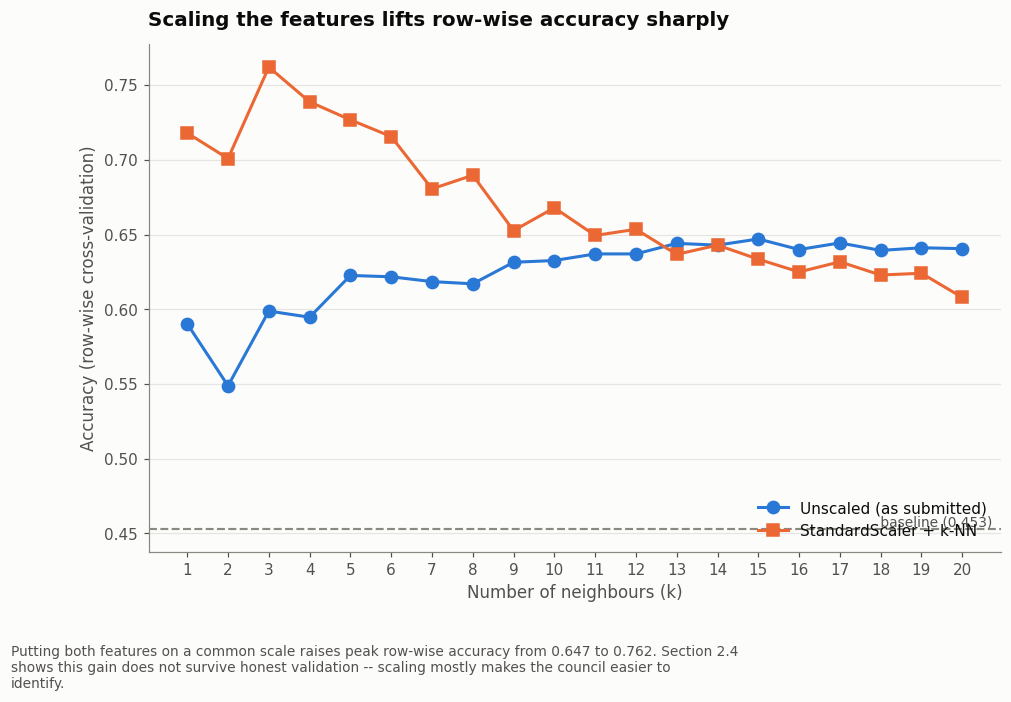

In [5]:
scaled = sweep[sweep["scaled"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    unscaled["k"], unscaled["rowwise_cv_mean"],
    marker="o", color=plotting.BLUE, label="Unscaled (as submitted)",
)
ax.plot(
    scaled["k"], scaled["rowwise_cv_mean"],
    marker="s", color=plotting.ORANGE, label="StandardScaler + k-NN",
)
plotting.annotate_baseline(ax, baseline, f"baseline ({baseline:.3f})")
ax.set_xticks(list(K_RANGE))
ax.set_xlabel("Number of neighbours (k)")
ax.set_ylabel("Accuracy (row-wise cross-validation)")
ax.set_title("Scaling the features lifts row-wise accuracy sharply")
ax.legend(loc="lower right")
plotting.caption(
    fig,
    "Putting both features on a common scale raises peak row-wise accuracy from "
    f"{unscaled['rowwise_cv_mean'].max():.3f} to {scaled['rowwise_cv_mean'].max():.3f}. "
    "Section 2.4 shows this gain does not survive honest validation -- scaling mostly makes the "
    "council easier to identify.",
)
plotting.save_fig(fig, "09_knn_scaled_vs_unscaled")
plt.show()

## 2.4 The leak, and what the model is worth without it

Notebook 1 established that 97% of the offence rate's variance and 89% of the
gambling rate's variance is between councils rather than within a council over
time, and that 25 of the 34 councils never change price band across the five
years.

So a row-wise split hands the model four near-copies of every test row. The fix
is to group the folds by council, so a council is either in training or in
testing but never both.

Model selection is also nested: k is chosen inside each outer fold, on the
training councils only. Choosing k on the same folds used to report the score
would bias the result upward, which matters here because the differences are
small.

In [6]:
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
inner = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)


def nested_grouped(estimator, grid):
    search = GridSearchCV(estimator, grid, cv=inner, scoring="accuracy")
    return cross_val_score(
        search, X, y, groups=groups, cv=outer, params={"groups": groups}
    )


nested = {
    "k-NN (unscaled)": nested_grouped(
        M.knn(1, scale=False), {"n_neighbors": list(K_RANGE)}
    ),
    "k-NN (scaled)": nested_grouped(
        M.knn(1, scale=True), {"knn__n_neighbors": list(K_RANGE)}
    ),
    "Decision tree (pruned)": nested_grouped(
        DecisionTreeClassifier(criterion="entropy", random_state=SEED),
        {"ccp_alpha": np.linspace(0, 0.05, 26), "max_depth": [2, 3, 4, 5, None]},
    ),
}

for name, scores in nested.items():
    stats = M.summarise(scores)
    print(
        f"{name:24s} {stats['mean']:.4f}  (sd {stats['sd']:.4f}, "
        f"95% CI {stats['ci_low']:.3f}-{stats['ci_high']:.3f})"
    )
print(f"{'majority baseline':24s} {baseline:.4f}")

k-NN (unscaled)          0.5162  (sd 0.1703, 95% CI 0.367-0.665)
k-NN (scaled)            0.4095  (sd 0.1387, 95% CI 0.288-0.531)
Decision tree (pruned)   0.5095  (sd 0.0946, 95% CI 0.427-0.592)
majority baseline        0.4529


In [7]:
# The comparison that matters: the same models under the original protocol and
# under council-grouped folds.
comparison = []
for name, scores in nested.items():
    if name.startswith("k-NN"):
        # "unscaled" contains "scaled" as a substring, so match the exact label.
        subset = sweep[sweep["scaled"] == (name == "k-NN (scaled)")]
        rowwise = subset["rowwise_cv_mean"].max()
    else:
        tree = DecisionTreeClassifier(criterion="entropy", random_state=SEED)
        rowwise = M.repeated_stratified_cv(tree, X, y).mean()
    stats = M.summarise(scores)
    comparison.append(
        {
            "Model": name,
            "Row-wise CV (leaky)": rowwise,
            "Grouped CV (honest)": stats["mean"],
            "Grouped CV sd": stats["sd"],
            "Grouped CV CI low": stats["ci_low"],
            "Grouped CV CI high": stats["ci_high"],
        }
    )
comparison = pd.DataFrame(comparison)
comparison.round(4).to_csv(RESULTS / "model_comparison.csv", index=False)
comparison.round(4)

,Model,Row-wise CV (leaky),Grouped CV (honest),Grouped CV sd,Grouped CV CI low,Grouped CV CI high
0,k-NN (unscaled),0.6471,0.5162,0.1703,0.3669,0.6655
1,k-NN (scaled),0.7621,0.4095,0.1387,0.2880,0.5311
2,Decision tree (pruned),0.6868,0.5095,0.0946,0.4266,0.5925


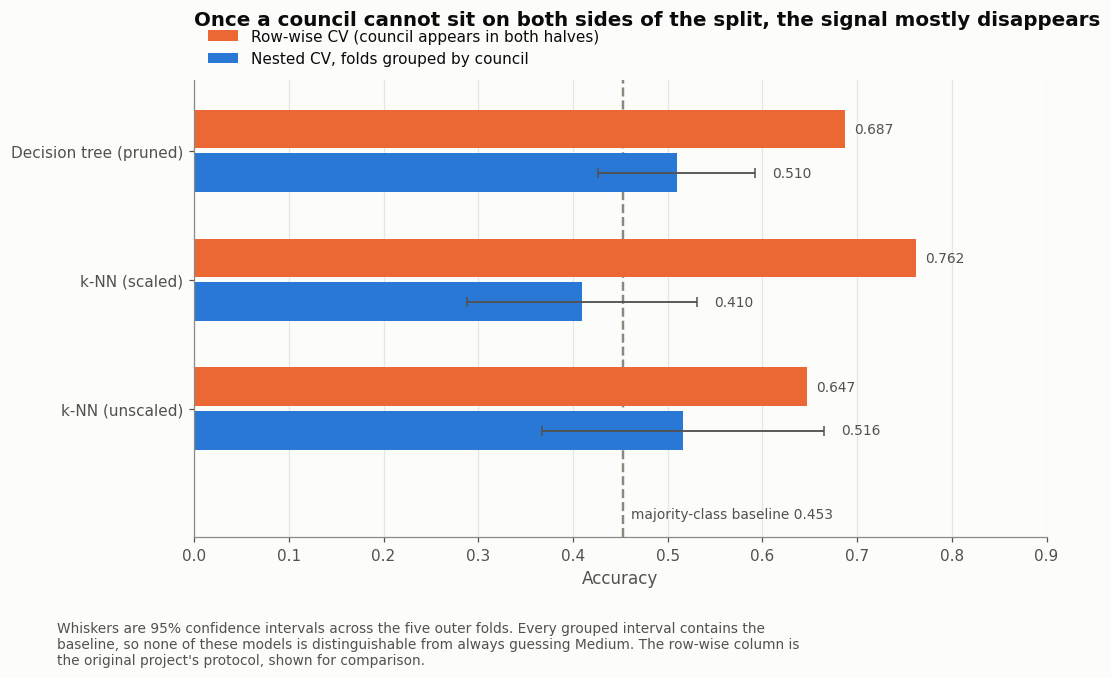

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.4))
positions = np.arange(len(comparison))
height = 0.3
gap = 0.17

ax.barh(
    positions + gap, comparison["Row-wise CV (leaky)"],
    height=height, color=plotting.ORANGE, label="Row-wise CV (council appears in both halves)",
    zorder=2,
)
ax.barh(
    positions - gap, comparison["Grouped CV (honest)"],
    height=height, color=plotting.BLUE, label="Nested CV, folds grouped by council",
    zorder=2,
)
ax.errorbar(
    comparison["Grouped CV (honest)"], positions - gap,
    xerr=[
        comparison["Grouped CV (honest)"] - comparison["Grouped CV CI low"],
        comparison["Grouped CV CI high"] - comparison["Grouped CV (honest)"],
    ],
    fmt="none", ecolor=plotting.INK_SECONDARY, elinewidth=1.2, capsize=3, zorder=3,
)

# Reference line, labelled in the clear space below the lowest bar so it
# collides with neither the title nor the bars.
ax.axvline(baseline, color=plotting.REFERENCE, linestyle="--", linewidth=1.6, zorder=1)
ax.set_ylim(-1.0, len(comparison) - 0.45)
ax.text(
    baseline + 0.008, -0.82, f"majority-class baseline {baseline:.3f}",
    color=plotting.INK_SECONDARY, fontsize=9, va="center",
)

# Value labels sit clear of the whisker ends.
for pos, row in comparison.iterrows():
    ax.text(
        row["Row-wise CV (leaky)"] + 0.01, pos + gap,
        f"{row['Row-wise CV (leaky)']:.3f}",
        va="center", fontsize=9, color=plotting.INK_SECONDARY,
    )
    ax.text(
        row["Grouped CV CI high"] + 0.018, pos - gap,
        f"{row['Grouped CV (honest)']:.3f}",
        va="center", fontsize=9, color=plotting.INK_SECONDARY,
    )

ax.set_yticks(positions)
ax.set_yticklabels(comparison["Model"])
ax.set_xlim(0, 0.9)
ax.set_xlabel("Accuracy")
ax.set_title(
    "Once a council cannot sit on both sides of the split, the signal mostly disappears",
    pad=36,
)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=1)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plotting.caption(
    fig,
    "Whiskers are 95% confidence intervals across the five outer folds. Every grouped interval "
    "contains the baseline, so none of these models is distinguishable from always guessing "
    "Medium. The row-wise column is the original project's protocol, shown for comparison.",
)
plotting.save_fig(fig, "08_model_comparison")
plt.show()

This is the central result of the re-analysis.

Under the original row-wise protocol the models look respectable. Under
council-grouped folds every one of them falls back towards the majority-class
baseline, and every confidence interval contains it. The relationship that the
original project reported as predictive is, on this data, not distinguishable
from guessing once councils cannot appear on both sides of the split.

Note also that scaling -- which helped considerably under the row-wise protocol
-- *hurts* under grouped folds. That is consistent with the leak: a scaled
two-feature fingerprint identifies a council more precisely, which helps only
when that council is also in the training set.

## 2.5 Where the errors fall

The confusion matrix below uses out-of-fold predictions under council-grouped
folds, so it describes held-out performance rather than performance on data the
model has already seen. The report's equivalent table was computed on a single
row-wise split.

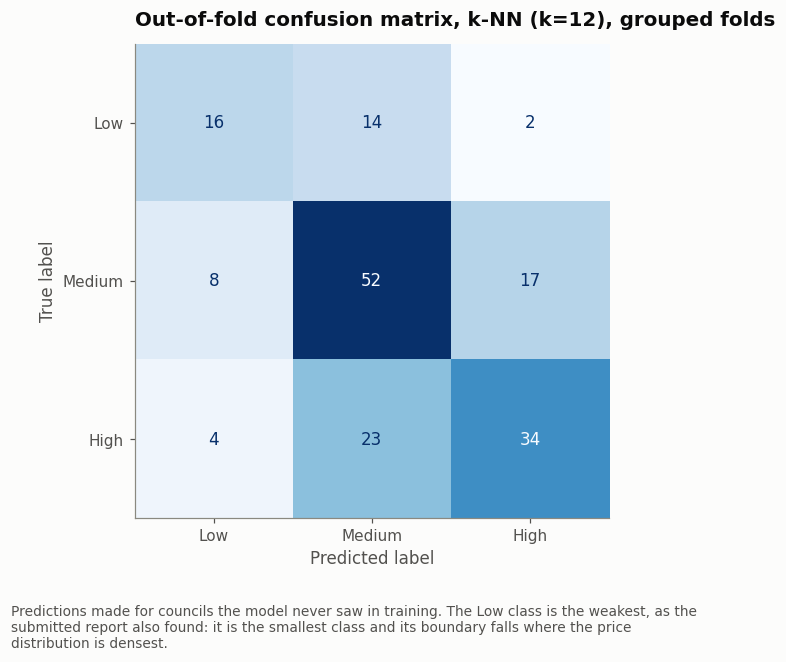

In [9]:
best_unscaled_k = int(
    unscaled.loc[unscaled["grouped_cv_mean"].idxmax(), "k"]
)
final_model = M.knn(best_unscaled_k, scale=False)
oof = M.grouped_predictions(final_model, X, y, groups)

matrix = confusion_matrix(y, oof, labels=PRICE_LABELS)
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ConfusionMatrixDisplay(matrix, display_labels=PRICE_LABELS).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title(f"Out-of-fold confusion matrix, k-NN (k={best_unscaled_k}), grouped folds")
ax.grid(False)
plotting.caption(
    fig,
    "Predictions made for councils the model never saw in training. The Low class is the "
    "weakest, as the submitted report also found: it is the smallest class and its boundary "
    "falls where the price distribution is densest.",
)
plotting.save_fig(fig, "07_knn_confusion_matrix")
plt.show()

In [10]:
summary = M.classification_summary(y, oof, PRICE_LABELS)
summary.to_csv(RESULTS / "classification_report.csv", index=False)
summary

,Class,Precision,Recall,F1,Support
0,Low,0.5714,0.5000,0.5333,32
1,Medium,0.5843,0.6753,0.6265,77
2,High,0.6415,0.5574,0.5965,61
3,macro average,0.5991,0.5776,0.5854,170
4,weighted average,0.6024,0.6000,0.5982,170


For comparison, the submitted report's hand-computed table (from a single
row-wise split) gave precision 0.50 / 0.67 / 0.86 and recall 0.40 / 0.77 / 0.80
for Low / Medium / High. The held-out figures above are the honest counterpart.

## 2.6 The decision tree the report left out

A decision tree appears in one of the original notebooks, scoring 0.7424 on a
single train-on-2016-2018, test-on-2019-2020 split. It was the best number
anywhere in the project and it did not make it into the report.

It was an unpruned tree on one split, so it was almost certainly overfitting,
and a year-based split does not fix the leak -- every council still appears on
both sides. Pruned and evaluated under grouped folds, it lands with the others.

selected: {'ccp_alpha': np.float64(0.04), 'max_depth': 4}


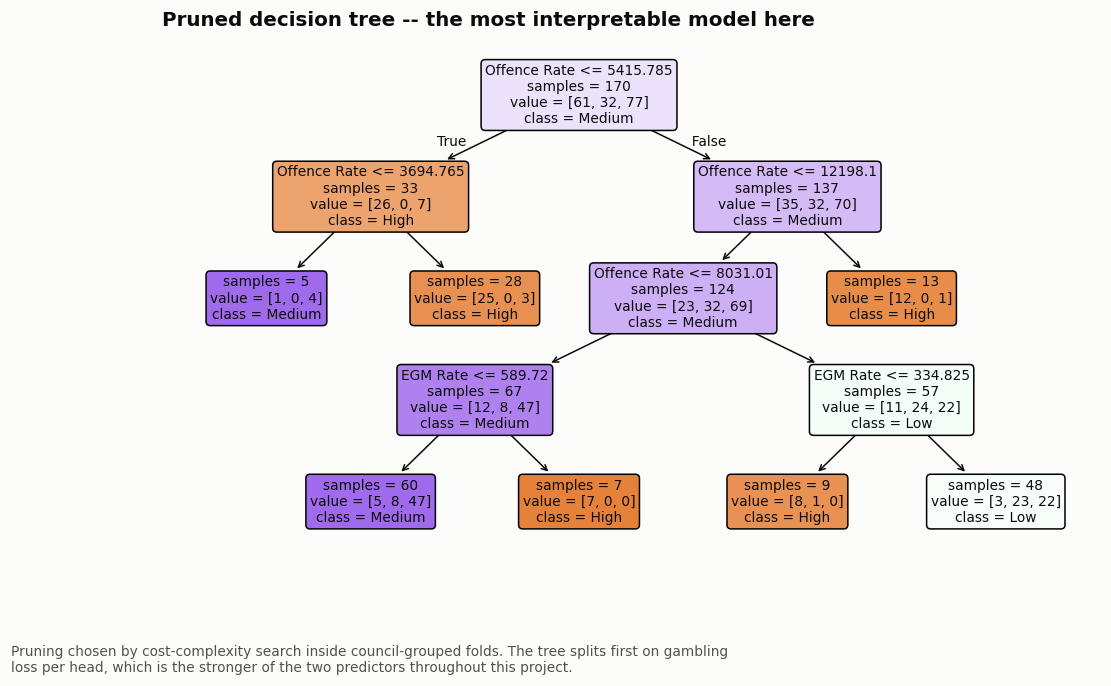

In [11]:
search = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy", random_state=SEED),
    {"ccp_alpha": np.linspace(0, 0.05, 26), "max_depth": [2, 3, 4, 5, None]},
    cv=inner,
    scoring="accuracy",
)
search.fit(X, y, groups=groups)
print("selected:", search.best_params_)

fig, ax = plt.subplots(figsize=(11, 6))
plot_tree(
    search.best_estimator_,
    feature_names=FEATURES,
    class_names=list(search.best_estimator_.classes_),
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=9,
    ax=ax,
)
ax.set_title("Pruned decision tree -- the most interpretable model here")
plotting.caption(
    fig,
    "Pruning chosen by cost-complexity search inside council-grouped folds. The tree splits "
    "first on gambling loss per head, which is the stronger of the two predictors throughout "
    "this project.",
)
plotting.save_fig(fig, "10_decision_tree")
plt.show()

## 2.7 The original project's other splits, reproduced

The report and its notebooks quote several further accuracies. They are
reproduced here under seeds, and all share the same flaw: every one of them is a
row-wise or year-wise split, so every council appears on both sides.

In [12]:
variants = []

for name, cols in [
    ("both features", FEATURES),
    ("gambling only", ["EGM Rate"]),
    ("offences only", ["Offence Rate"]),
]:
    train, test = M.year_split(df, [2016, 2017, 2018], [2019, 2020])
    model = M.knn(3, scale=False).fit(train[cols], train[TARGET])
    accuracy = (model.predict(test[cols]) == test[TARGET]).mean()
    variants.append(
        {"Variant": f"k=3, train 2016-18, test 2019-20, {name}", "Accuracy": accuracy}
    )

train, test = M.year_split(df, [2016, 2018, 2019], [2017, 2020])
model = M.knn(3, scale=False).fit(train[FEATURES], train[TARGET])
variants.append(
    {
        "Variant": "k=3, train 2016/18/19, test 2017/20, both features",
        "Accuracy": (model.predict(test[FEATURES]) == test[TARGET]).mean(),
    }
)

variants.append({"Variant": "majority-class baseline", "Accuracy": baseline})
variants.append(
    {
        "Variant": "k-NN, nested CV grouped by council (honest)",
        "Accuracy": M.summarise(nested["k-NN (unscaled)"])["mean"],
    }
)

variants = pd.DataFrame(variants)
variants.round(4).to_csv(RESULTS / "knn_variants.csv", index=False)
variants.round(4)

,Variant,Accuracy
0,"k=3, train 2016-18, test 2019-20, both features",0.6618
1,"k=3, train 2016-18, test 2019-20, gambling only",0.5147
2,"k=3, train 2016-18, test 2019-20, offences only",0.6471
3,"k=3, train 2016/18/19, test 2017/20, both feat...",0.6912
4,majority-class baseline,0.4529
5,"k-NN, nested CV grouped by council (honest)",0.5162


## 2.8 What this notebook established

* The majority-class baseline is **0.4529**, a number the original project never
  computed.
* Reproduced under the original row-wise protocol, k-NN scores in the mid-0.60s,
  consistent with the report's 0.66.
* The two features were never scaled, which is why gambling appeared almost
  useless on its own in the report's ablation.
* With folds grouped by council and k selected inside each fold, every model
  falls back towards the baseline and every confidence interval contains it.

The honest conclusion is that this dataset -- 34 councils over 5 years -- does
not support a predictive claim. Notebook 3 asks whether the underlying
*descriptive* relationship survives, which is a different and better-posed
question.